# Lipitor (20-702S025) — General Table Agent Eval

Runs the **router → bbox crop → general_table agent** pipeline on all 7 Lipitor tables.
Shows bounding box overlays, cropped images, side-by-side ground truth vs extracted tables, and per-table accuracy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, HTML

from shared.client import client, DEFAULT_MODEL
from shared.pdf import render_pages
from shared.eval import compare_tables, print_accuracy_summary
from shared.crop import crop_image
from agents.general_table.extract import extract_tables_from_page
from agents.router.classify import classify_page

In [2]:
MODEL = DEFAULT_MODEL
PAPER_ID = "lipitor_statr"
PDF_PATH = os.path.join("..", "papers", "20-702S025_Lipitor_statr", "paper.pdf")

catalog = pd.read_csv("../table_catalog.csv")
catalog["status"] = catalog["status"].str.strip()
eval_entries = catalog[catalog["paper_id"] == PAPER_ID].copy()

# Filter to page 5+ only for testing
eval_entries["first_page"] = eval_entries["page"].astype(str).str.split("-").str[0].astype(int)
eval_entries = eval_entries[eval_entries["first_page"] >= 5].drop(columns="first_page")

print(f"Lipitor tables to evaluate: {len(eval_entries)}")
eval_entries

Lipitor tables to evaluate: 5


,paper_id,page,figure_id,table_type,variation,description,ground_truth_path,cell_accuracy,row_match,notes,status
8,lipitor_statr,5,figC,efficacy_results,multiline_cells_subgroups,Percent of patients Meeting NCEP LDL-C criteri...,papers/20-702S025_Lipitor_statr/ground_truth/p...,NaN,NaN,NaN,not started
9,lipitor_statr,6,figD,efficacy_results,multiline_cells_subgroups,Percent of patients with persistent transamina...,papers/20-702S025_Lipitor_statr/ground_truth/p...,NaN,NaN,NaN,not started
10,lipitor_statr,12,fig3,study_schedule,sparse_markers_spanning_headers,Schedule of Study Evaluations and Procedures,papers/20-702S025_Lipitor_statr/ground_truth/p...,NaN,NaN,NaN,not started
11,lipitor_statr,13,fig6,demographics,hierarchical_rows_mixed_format,Demographics and baseline characteristics,papers/20-702S025_Lipitor_statr/ground_truth/p...,NaN,NaN,NaN,not started
12,lipitor_statr,14,fig9,patient_disposition,hierarchical_rows_n_percent,Summary of Patient Disposition,papers/20-702S025_Lipitor_statr/ground_truth/p...,NaN,NaN,NaN,not started


In [3]:
# Render all needed pages once (cache across tables)
all_pages = set()
for _, row in eval_entries.iterrows():
    for p in str(row["page"]).split("-"):
        all_pages.add(int(p))

print(f"Rendering pages: {sorted(all_pages)}")
page_images = render_pages(PDF_PATH, sorted(all_pages))
print(f"Rendered {len(page_images)} pages")

Rendering pages: [5, 6, 12, 13, 14]
Rendered 5 pages



figC — Percent of patients Meeting NCEP LDL-C criteria at initial dose (Week 54)  (page 5)
Ground truth: 4 rows x 6 cols
Router found 2 table(s):
  [0] Table A (general_table) — This table displays mean percent reduction in LDL-C from baseline at week 6 for various statins, stratified by age subgroups (<70 years and ≥ 70 years).
  [1] Table B (general_table) — Table B presents the percentage of patients meeting NCEP LDL-C criteria at Week 6, including ITT population totals and age subgroup analyses.


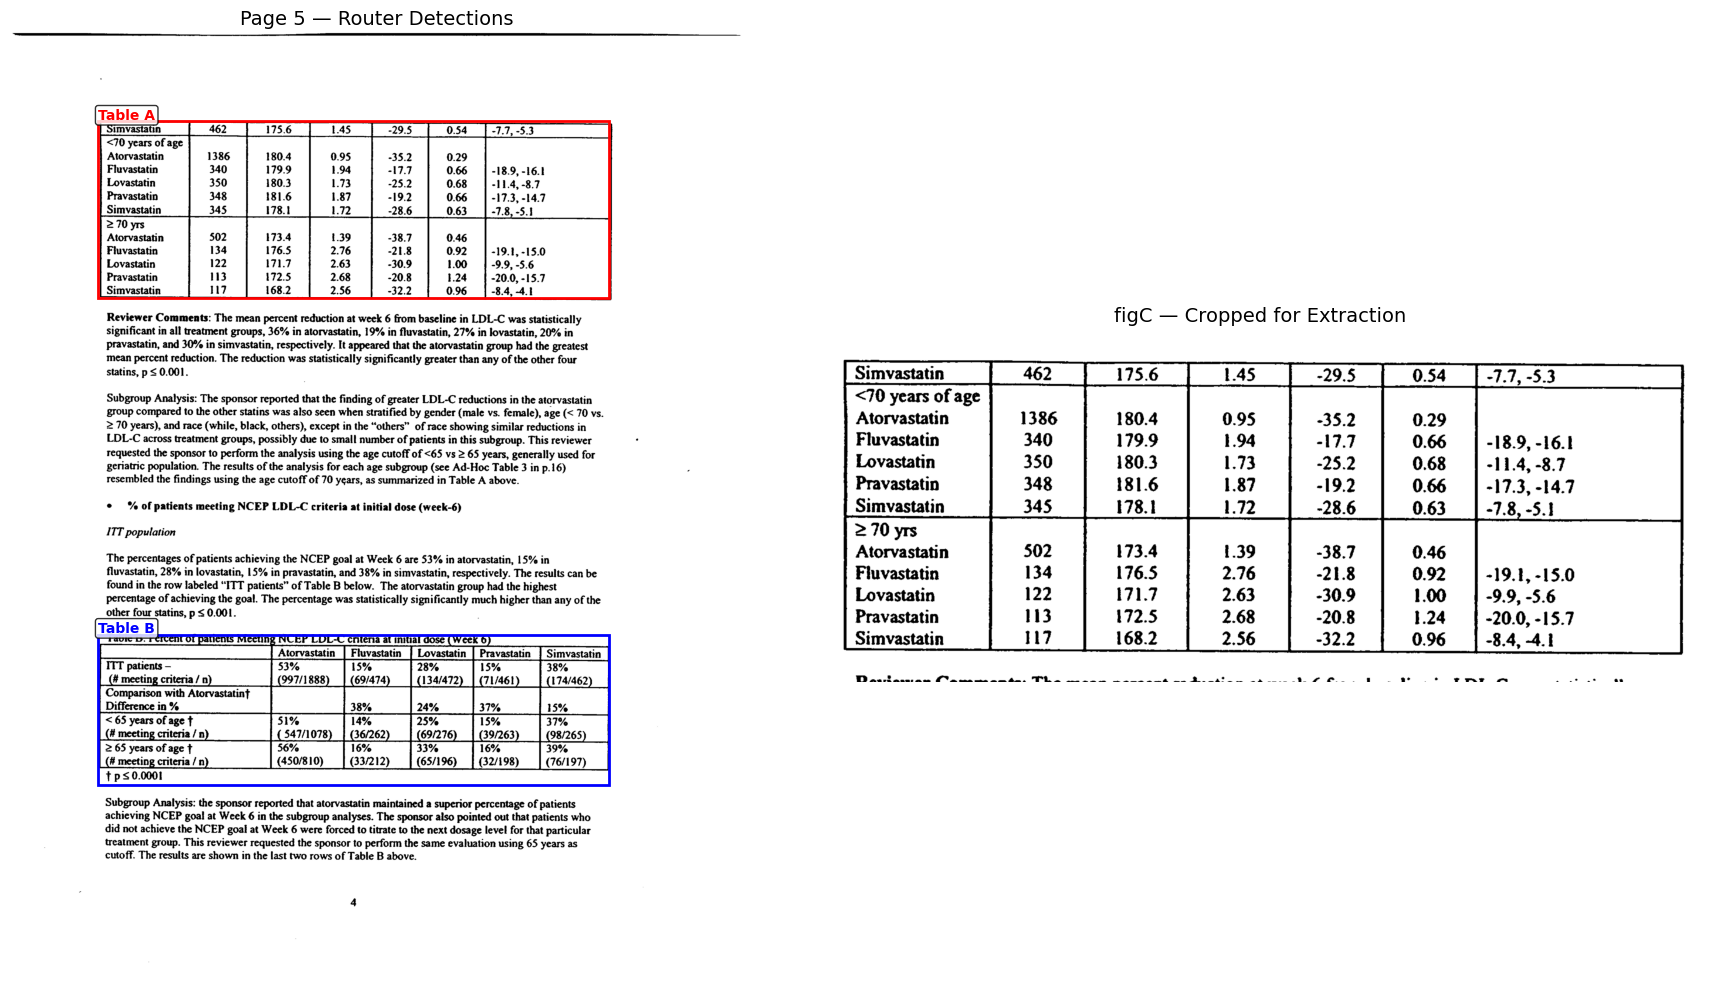

  Page 5: 1 segment(s)
    headers=['', '', '', '', '', '', '']  rows=13
  Extracted: 13 rows x 7 cols


ACCURACY SUMMARY
Ground truth rows:  4
Extracted rows:     13
Rows compared:      4
Missing rows:       0
Extra rows:         9

Total cells compared: 24
Correct cells:        1
Cell accuracy:        4.2%
Row match:            0.0%  (0/4 rows fully correct)

DETAILED MISMATCHES (23 cells)


,Row,Column,Ground Truth,Extracted
0,0,unnamed: 0,itt patients - (# meeting criteria / n),simvastatin
1,1,unnamed: 0,comparison with atorvastatin† difference in %,<70 years of age
2,2,unnamed: 0,< 65 years of age (# meeting criteria / n),atorvastatin
3,3,unnamed: 0,≥ 65 years of age (# meeting criteria / n),fluvastatin
4,0,atorvastatin,76% (1452/1902),462
5,2,atorvastatin,74% (803/1087),1386
6,3,atorvastatin,80% (649/815),340
7,0,fluvastatin,37% (178/477),1756
8,1,fluvastatin,39%,
9,2,fluvastatin,34% (90/265),1804



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,unnamed: 0,4,0,4,0.0%
1,atorvastatin,4,1,3,25.0%
2,fluvastatin,4,0,4,0.0%
3,lovastatin,4,0,4,0.0%
4,pravastatin,4,0,4,0.0%
5,simvastatin,4,0,4,0.0%



figD — Percent of patients with persistent transaminase elevations – Sensitivity Analyses  (page 6)
Ground truth: 3 rows x 5 cols
Router found 1 table(s):
  [0] Table C (general_table) — This table presents the percentage of ITT patients and age subgroups achieving NCEP LDL-C criteria at week 54 across five different statin treatments (Atorvastatin, Fluvastatin, Lovastatin, Pravastatin, and Simvastatin).


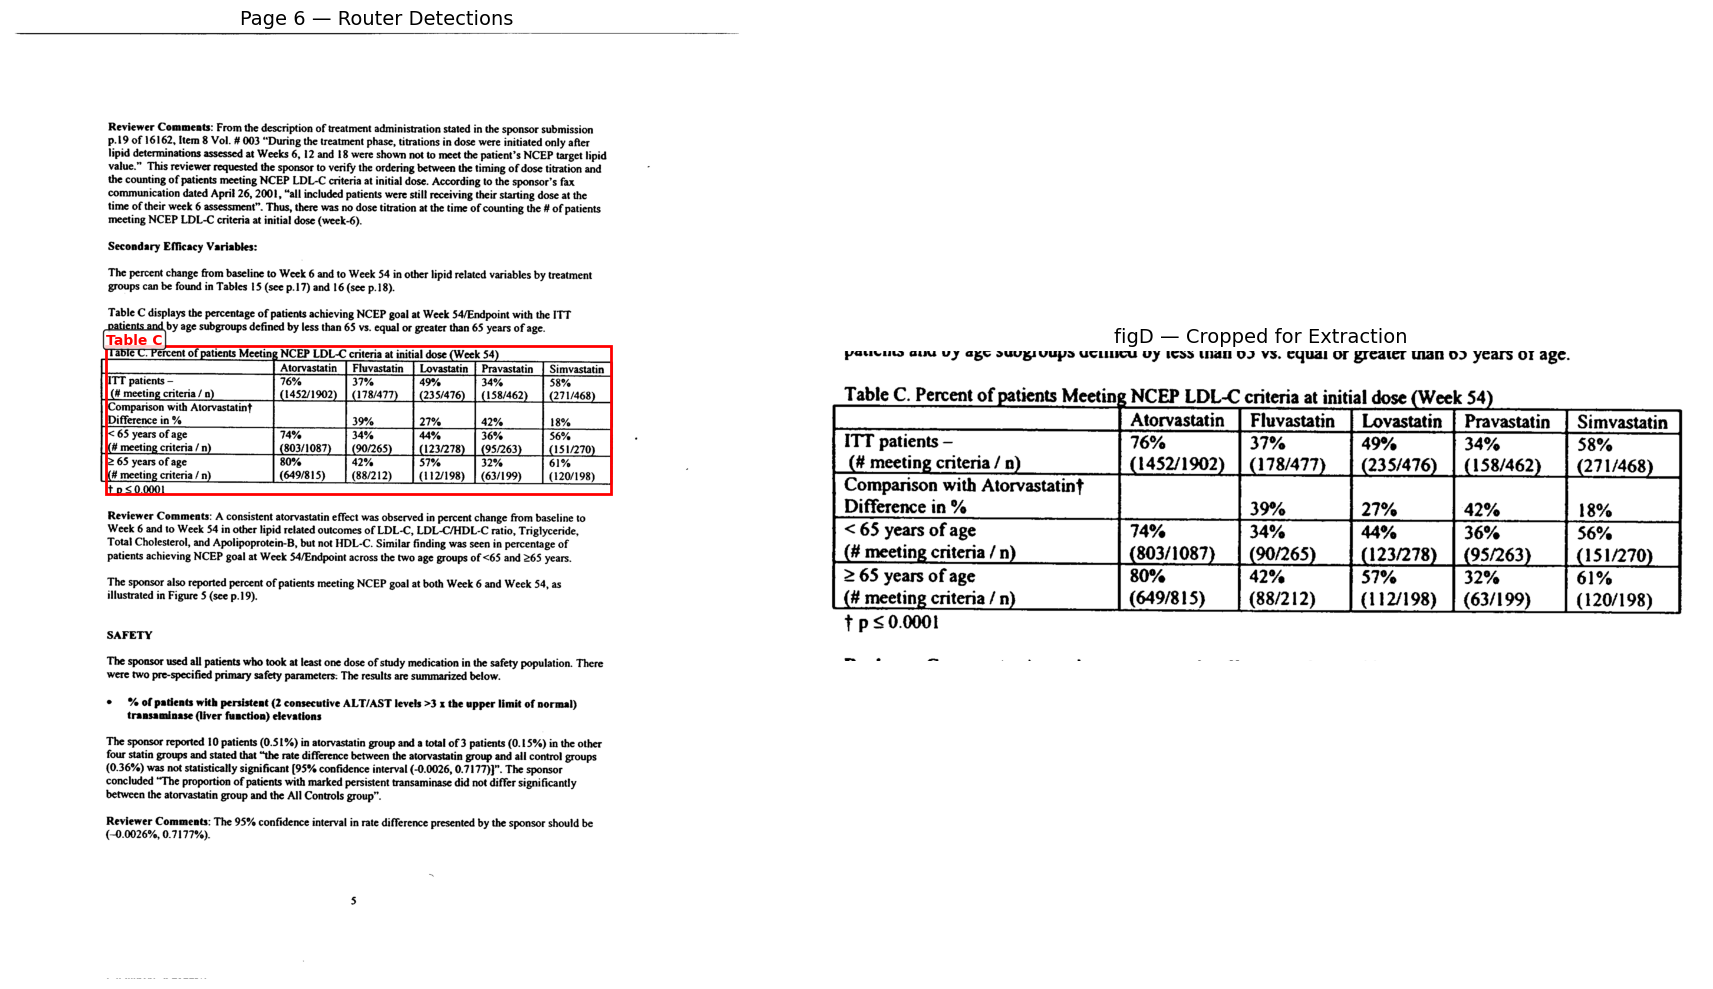

  Page 6: 1 segment(s)
    headers=['', 'Atorvastatin', 'Fluvastatin', 'Lovastatin', 'Pravastatin', 'Simvastatin']  rows=6
  Extracted: 6 rows x 6 cols


ACCURACY SUMMARY
Ground truth rows:  3
Extracted rows:     6
Rows compared:      3
Missing rows:       0
Extra rows:         3

Total cells compared: 15
Correct cells:        0
Cell accuracy:        0.0%
Row match:            0.0%  (0/3 rows fully correct)

DETAILED MISMATCHES (15 cells)


,Row,Column,Ground Truth,Extracted
0,0,unnamed: 0,data observed % (# with event / n),table c percent of patients meeting ncep ldl-c...
1,1,unnamed: 0,sensitivity analysis - 1,itt patients - (# meeting criteria / n)
2,2,unnamed: 0,sensitivity analysis - 2,comparison with atorvastatin† difference in %
3,0,atorvastatin,051% 10/1958,
4,1,atorvastatin,051% 10/1958,76% (1452/1902)
5,2,atorvastatin,056% 11/1958,
6,0,all controls group (all other statins),015% 3/1958,
7,1,all controls group (all other statins),010% 2/1957,37% (178/477)
8,2,all controls group (all other statins),015% 3/1958,39%
9,0,rr (95% ci),3 (1 11),



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,unnamed: 0,3,0,3,0.0%
1,atorvastatin,3,0,3,0.0%
2,all controls group (all other statins),3,0,3,0.0%
3,rr (95% ci),3,0,3,0.0%
4,nominal p-value,3,0,3,0.0%



fig3 — Schedule of Study Evaluations and Procedures  (page 12)
Ground truth: 19 rows x 12 cols
Router found 1 table(s):
  [0] Figure 1 (general_table) — Study design schematic showing drug dosages for various statins and the timeline of the clinical trial phases.


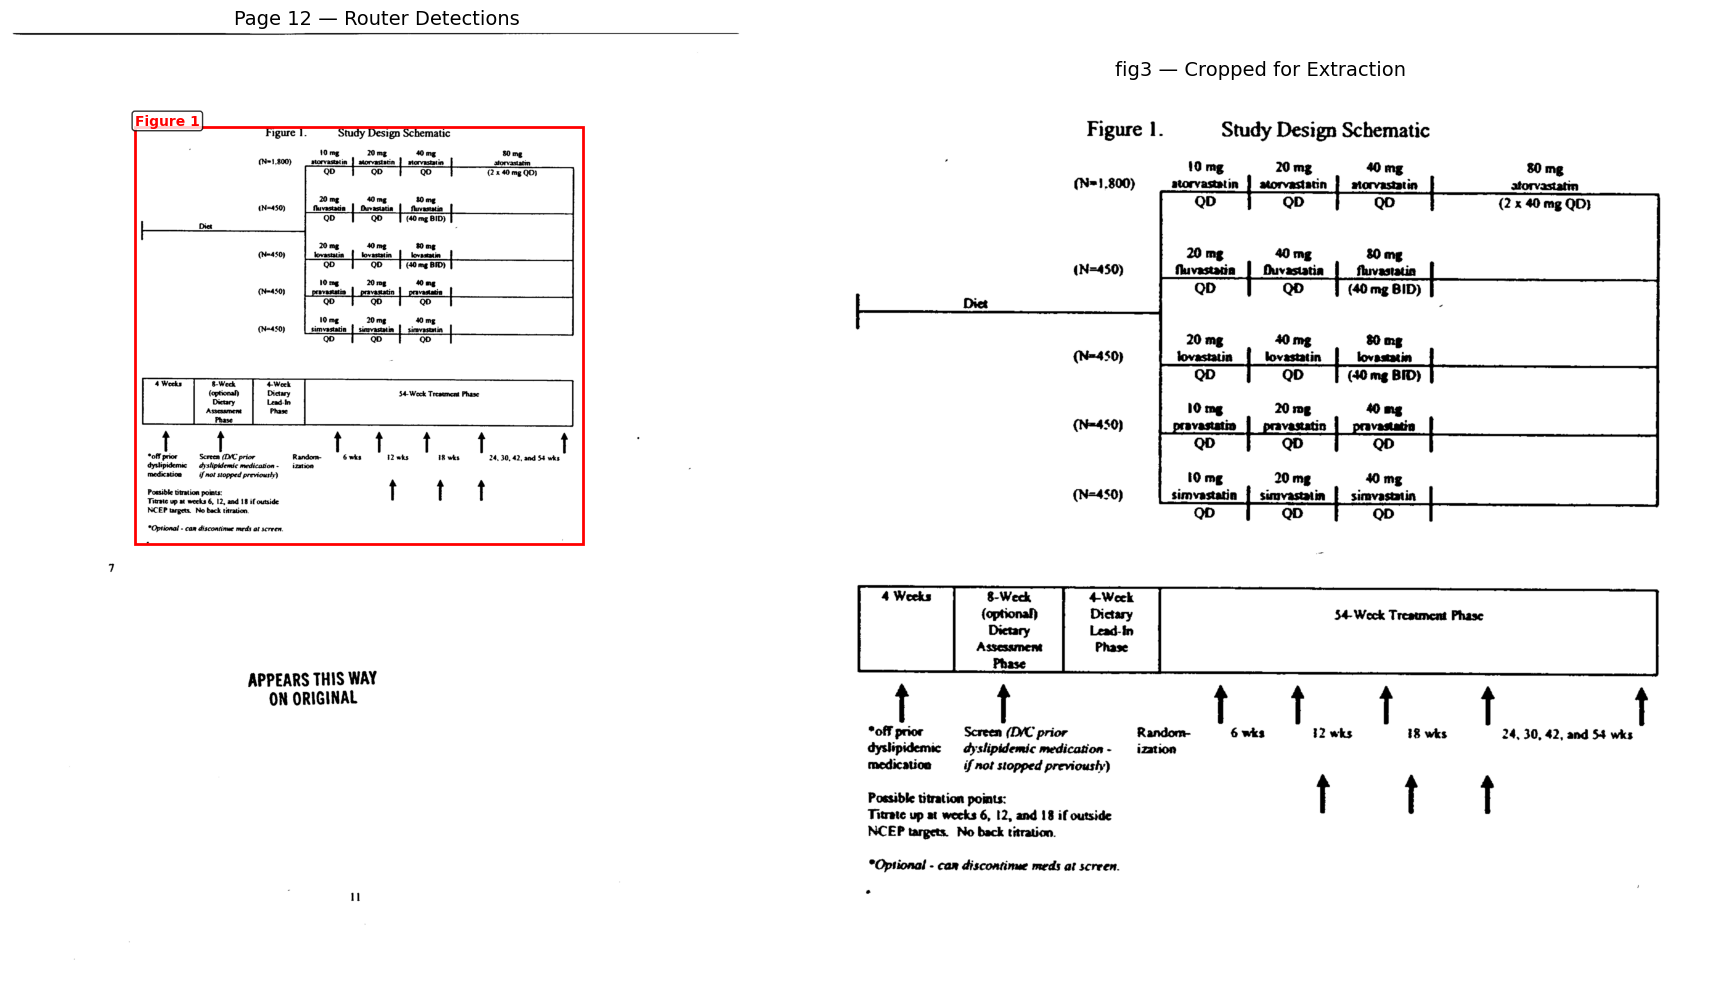

  Page 12: 2 segment(s)
    headers=['', '', '', '', '']  rows=5
    headers=['4 Weeks', '8-Week (optional) Dietary Assessment Phase', '4-Week Dietary Lead-In Phase', '54-Week Treatment Phase']  rows=1
  Extracted: 5 rows x 5 cols


Study Phase,Screening*,Lead-In Phase,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Treatment Phase,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
Visit Designation,1,2,3,4,5,6,7,8,9,10,11
Study Week,NaN,-4,-2,0,6,12,18,24,30,42,54***
Titration Schedule**,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atorvastatin,NaN,NaN,NaN,10,A,B,C,NaN,NaN,NaN,NaN
"simvastatin, pravastatin",NaN,NaN,NaN,10,A,B,NaN,NaN,NaN,NaN,NaN
"lovastatin, fluvastatin",NaN,NaN,NaN,20,B,C,NaN,NaN,NaN,NaN,NaN
Procedures,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Hx,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Weight, Blood Pressure",X,X,X,X,X,X,X,X,X,X,X
Physical Exam,NaN,NaN,NaN,X,NaN,NaN,NaN,NaN,NaN,NaN,X^5


ACCURACY SUMMARY
Ground truth rows:  19
Extracted rows:     5
Rows compared:      5
Missing rows:       14
Extra rows:         0

Total cells compared: 25
Correct cells:        1
Cell accuracy:        4.0%
Row match:            0.0%  (0/5 rows fully correct)

DETAILED MISMATCHES (24 cells)


,Row,Column,Ground Truth,Extracted
0,0,study phase,visit designation,(n=1800)
1,1,study phase,study week,(n=450)
2,2,study phase,titration schedule**,(n=450)
3,3,study phase,atorvastatin,(n=450)
4,4,study phase,simvastatin pravastatin,(n=450)
5,0,screening*,1,10 mg atorvastatin qd
6,1,screening*,,20 mg fluvastatin qd
7,2,screening*,,20 mg lovastatin qd
8,3,screening*,,10 mg pravastatin qd
9,4,screening*,,10 mg simvastatin qd



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,study phase,5,0,5,0.0%
1,screening*,5,0,5,0.0%
2,lead-in phase,5,0,5,0.0%
3,unnamed: 3,5,0,5,0.0%
4,unnamed: 4,5,1,4,20.0%



fig6 — Demographics and baseline characteristics  (page 13)
Ground truth: 43 rows x 11 cols
Router found 1 table(s):
  [0] Table 3 (general_table) — A schedule of study evaluations and procedures across screening, lead-in, and treatment phases.


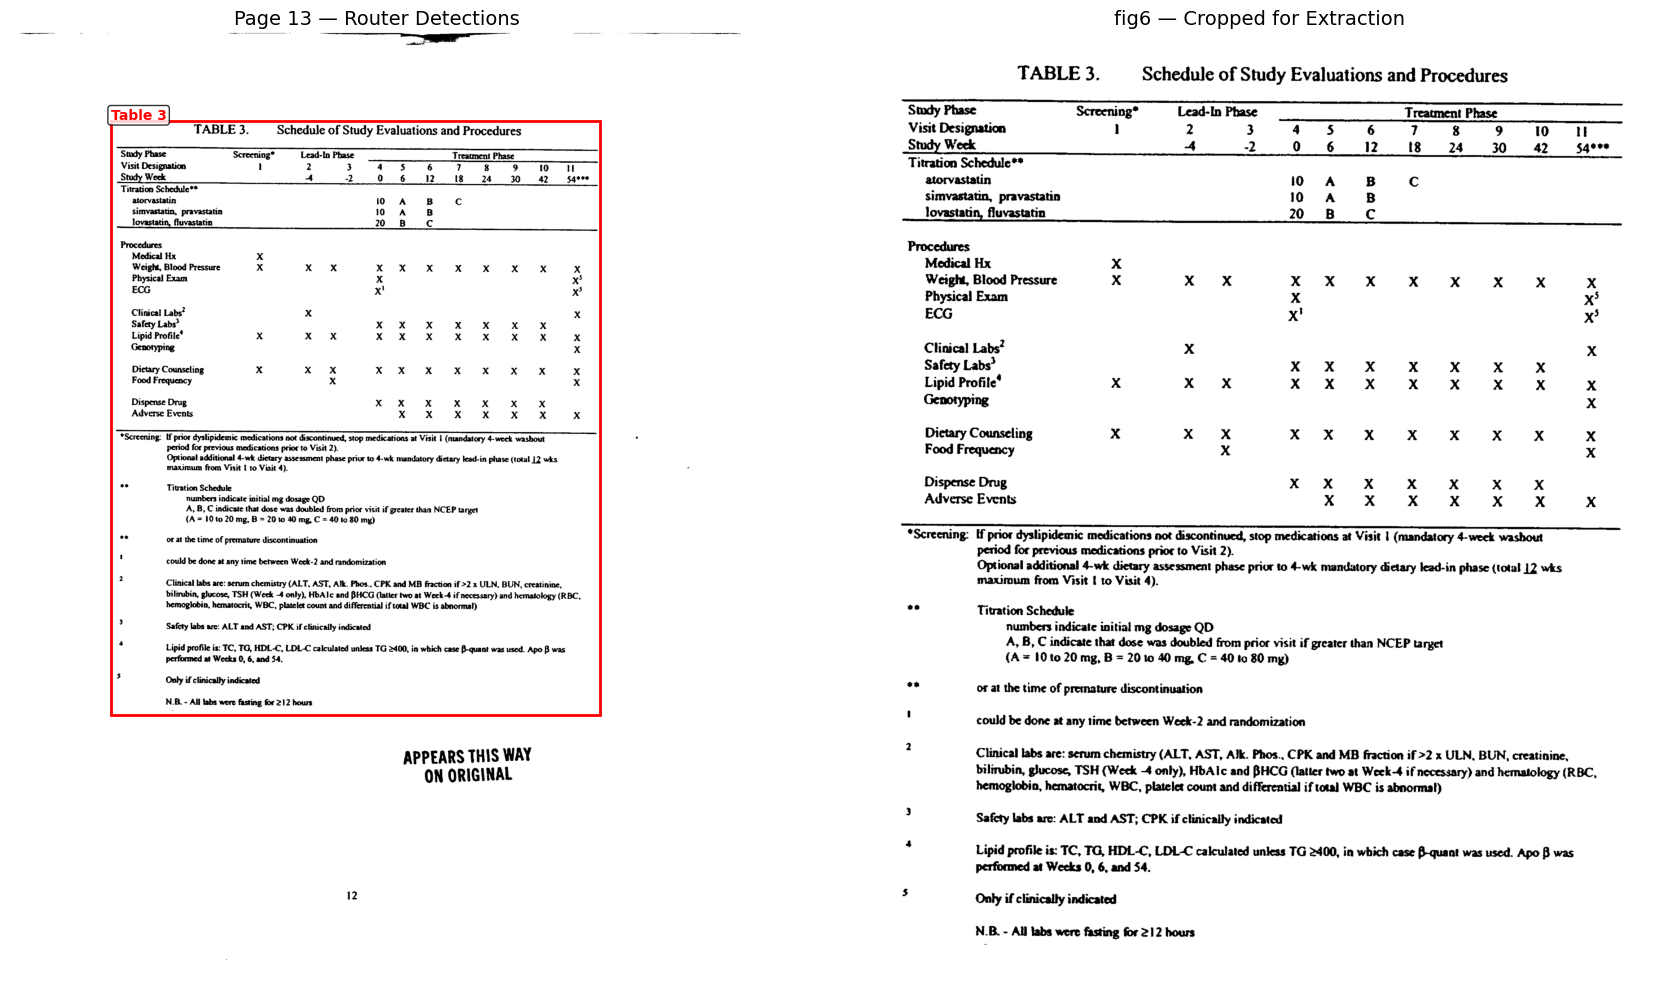

  Page 13: 1 segment(s)
    headers=['Visit Designation', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']  rows=32
  Extracted: 32 rows x 12 cols


Unnamed: 0,Atorvastatin (N = 1902),Unnamed: 2,Fluvastatin (N = 477),Unnamed: 4,Lovastatin (N = 476),Unnamed: 6,Pravastatin (N = 462),Unnamed: 8,Simvastatin (N = 468),Unnamed: 10
Variable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age (years),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,1902.0,NaN,477.0,NaN,476.0,NaN,462.0,NaN,468.0,NaN
Mean (SE),61.3,0.2,61.4,0.5,61.5,0.5,61.1,0.5,60.9,0.5
Age Distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
<70 years,1396.0,NaN,343.0,NaN,353.0,NaN,349.0,NaN,351.0,NaN
≥70 years,506.0,NaN,134.0,NaN,123.0,NaN,113.0,NaN,117.0,NaN
Race n (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
White/Caucasian,1682.0,88.4,425.0,89.1,433.0,91.0,410.0,88.7,417.0,89.1
Black,130.0,6.8,27.0,5.7,25.0,5.3,24.0,5.2,28.0,6.0


ACCURACY SUMMARY
Ground truth rows:  43
Extracted rows:     32
Rows compared:      32
Missing rows:       11
Extra rows:         0

Total cells compared: 352
Correct cells:        99
Cell accuracy:        28.1%
Row match:            0.0%  (0/32 rows fully correct)

DETAILED MISMATCHES (253 cells)


,Row,Column,Ground Truth,Extracted
0,0,unnamed: 0,variable,study phase
1,1,unnamed: 0,age (years),study week
2,2,unnamed: 0,n,titration schedule**
3,3,unnamed: 0,mean (se),atorvastatin
4,4,unnamed: 0,age distribution,simvastatin pravastatin
...,...,...,...,...
248,21,unnamed: 10,647,
249,23,unnamed: 10,630,
250,24,unnamed: 10,370,
251,27,unnamed: 10,14,



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,unnamed: 0,32,0,32,0.0%
1,atorvastatin (n = 1902),32,8,24,25.0%
2,unnamed: 2,32,14,18,43.8%
3,fluvastatin (n = 477),32,9,23,28.1%
4,unnamed: 4,32,11,21,34.4%
5,lovastatin (n = 476),32,6,26,18.8%
6,unnamed: 6,32,11,21,34.4%
7,pravastatin (n = 462),32,7,25,21.9%
8,unnamed: 8,32,13,19,40.6%
9,simvastatin (n = 468),32,7,25,21.9%



fig9 — Summary of Patient Disposition  (page 14)
Ground truth: 16 rows x 11 cols
Router found 1 table(s):
  [0] Table 6 (general_table) — This table provides a summary of background information and baseline characteristics for the ITT population, categorized by the specific statin medication administered.


ValueError: Coordinate 'right' is less than 'left'

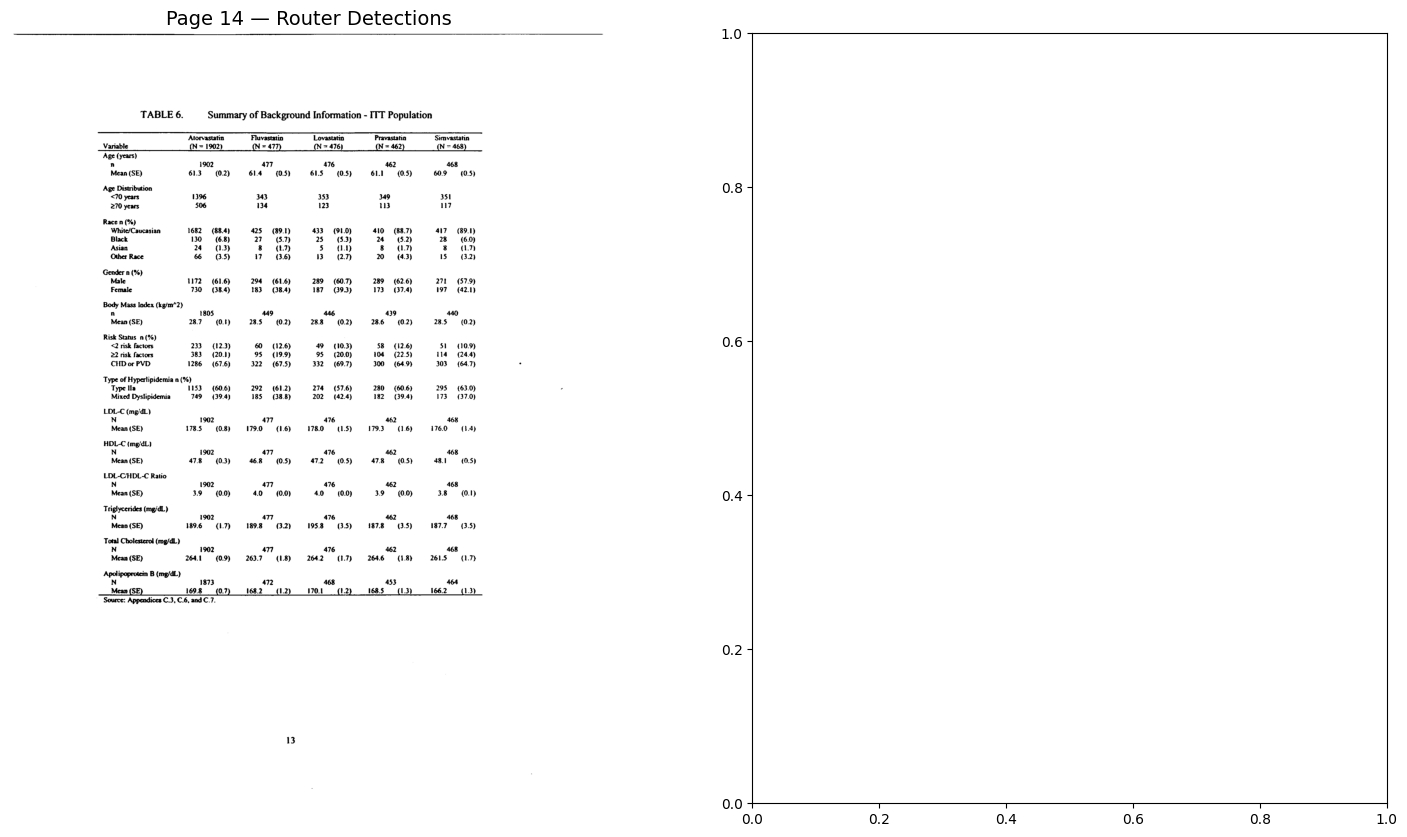

In [4]:
# Run router + extraction for each table
results = []
os.makedirs("../output", exist_ok=True)

for _, row in eval_entries.iterrows():
    figure_id = row["figure_id"]
    gt_path = os.path.join("..", row["ground_truth_path"])
    pages = [int(p) for p in str(row["page"]).split("-")]

    print(f"\n{'=' * 70}")
    print(f"{figure_id} — {row['description']}  (page {row['page']})")
    print(f"{'=' * 70}")

    # Load ground truth
    df_truth = pd.read_csv(gt_path)
    print(f"Ground truth: {len(df_truth)} rows x {len(df_truth.columns)} cols")

    # Use first page for router classification + bbox visualization
    page_num = pages[0]
    page_image = page_images[page_num]

    # --- Router classification ---
    classification = classify_page(client, MODEL, page_image)
    print(f"Router found {len(classification.tables)} table(s):")
    for i, t in enumerate(classification.tables):
        print(f"  [{i}] {t.label} ({t.type}) — {t.description}")

    # Pick the best matching router entry
    router_entry = None
    for t in classification.tables:
        if t.type == "general_table":
            router_entry = t
            break
    if router_entry is None and classification.tables:
        router_entry = classification.tables[0]

    # --- Bbox visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))

    # Left: full page with ALL detected bboxes
    axes[0].imshow(page_image)
    axes[0].set_title(f"Page {page_num} — Router Detections", fontsize=14)
    colors = ["red", "blue", "green", "orange", "purple"]
    w, h = page_image.size
    for i, t in enumerate(classification.tables):
        if t.bbox is not None:
            bd = t.bbox.model_dump()
            x = w * bd["x_min"] / 100
            y = h * bd["y_min"] / 100
            bw = w * (bd["x_max"] - bd["x_min"]) / 100
            bh = h * (bd["y_max"] - bd["y_min"]) / 100
            color = colors[i % len(colors)]
            rect = patches.Rectangle((x, y), bw, bh, linewidth=2,
                                     edgecolor=color, facecolor="none")
            axes[0].add_patch(rect)
            axes[0].text(x, y - 10, t.label, color=color, fontsize=10,
                         fontweight="bold", bbox=dict(boxstyle="round,pad=0.2",
                         facecolor="white", alpha=0.8))
    axes[0].axis("off")

    # Right: cropped image for extraction
    if router_entry and router_entry.bbox is not None:
        bbox_dict = router_entry.bbox.model_dump()
        extract_image = crop_image(page_image, bbox_dict)
        axes[1].set_title(f"{figure_id} — Cropped for Extraction", fontsize=14)
    else:
        bbox_dict = None
        extract_image = page_image
        axes[1].set_title(f"{figure_id} — Full Page (no bbox)", fontsize=14)
    axes[1].imshow(extract_image)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    # --- Multi-page extraction with continuation_headers ---
    page_results = {}
    continuation_headers = None
    for p in pages:
        img = page_images[p]
        # Crop first page if we have a bbox
        if p == pages[0] and bbox_dict:
            img = crop_image(img, bbox_dict)
        instruction = router_entry.instruction if router_entry else None
        try:
            page_result = extract_tables_from_page(
                client, MODEL, img,
                continuation_headers=continuation_headers,
                instruction=instruction,
            )
        except Exception as e:
            print(f"  API error on page {p}: {e}")
            continue
        page_results[p] = page_result
        print(f"  Page {p}: {len(page_result.tables)} segment(s)")
        for seg in page_result.tables:
            print(f"    headers={seg.headers!r}  rows={len(seg.rows)}")
        # Pass last segment's headers to next page if table is incomplete
        if page_result.tables:
            last_seg = page_result.tables[-1]
            if not last_seg.table_appears_complete:
                continuation_headers = last_seg.headers or continuation_headers
            else:
                continuation_headers = None

    # --- Build DataFrames using stitch_page_results for multi-page ---
    from agents.general_table.extract import stitch_page_results

    if len(pages) > 1 and page_results:
        dfs = stitch_page_results(page_results)
    else:
        # Single page: build directly (handles headerless segments)
        dfs = []
        for seg in (page_results.get(pages[0]).tables if page_results else []):
            if not seg.rows:
                continue
            if seg.headers:
                dfs.append(pd.DataFrame(seg.rows, columns=seg.headers))
            else:
                dfs.append(pd.DataFrame(seg.rows))

    if not dfs:
        print("  No tables extracted!")
        results.append({"figure_id": figure_id, "total_cells": 0, "correct_cells": 0})
        continue

    # Take the largest extracted table
    df_extracted = max(dfs, key=lambda d: d.size)
    print(f"  Extracted: {len(df_extracted)} rows x {len(df_extracted.columns)} cols")

    # Save
    out_path = f"../output/lipitor_{figure_id}.csv"
    df_extracted.to_csv(out_path, index=False)

    # --- Side-by-side display ---
    display(HTML(
        '<div style="display:flex; gap:2em; overflow-x:auto;">'
        '<div><h4>Ground Truth</h4>' + df_truth.to_html(index=False) + '</div>'
        '<div><h4>Extracted</h4>' + df_extracted.to_html(index=False) + '</div>'
        '</div>'
    ))

    # --- Accuracy ---
    result = compare_tables(df_truth, df_extracted)
    result["figure_id"] = figure_id
    results.append(result)
    print_accuracy_summary(result)

In [ ]:
# Aggregate accuracy
evaluated = [r for r in results if r.get("total_cells", 0) > 0]
if evaluated:
    total_cells = sum(r["total_cells"] for r in evaluated)
    correct_cells = sum(r["correct_cells"] for r in evaluated)
    total_rows = sum(r["rows_compared"] for r in evaluated)
    rows_correct = sum(r["rows_fully_correct"] for r in evaluated)
    print(f"{'=' * 60}")
    print(f"LIPITOR AGGREGATE ACROSS {len(evaluated)}/{len(results)} TABLES")
    print(f"{'=' * 60}")
    print(f"Cell accuracy:  {correct_cells}/{total_cells} = {correct_cells/total_cells:.1%}")
    print(f"Row match:      {rows_correct}/{total_rows} = {rows_correct/total_rows:.1%}")
    print(f"Tables with no extraction: {len(results) - len(evaluated)}")
    print()
    # Per-table summary
    summary = pd.DataFrame([{
        "figure": r["figure_id"],
        "cell_acc": f"{r['correct_cells']}/{r['total_cells']} ({r['cell_accuracy']:.1%})",
        "row_match": f"{r['rows_fully_correct']}/{r['rows_compared']} ({r['row_match']:.1%})",
    } for r in evaluated])
    display(summary)
else:
    print("No tables were evaluated.")